<b><font size="10" color="#E8800A">Notebook 1 · Data Exploration </font></b><br>
<b><font size="6">Importação e análise inicial dos dados em bruto</font></b><br>

**Objetivo.** Observar e diagnosticar os dados em bruto (`train.csv`, `test.csv` e `clientes.csv`): estrutura, qualidade, distribuições, relação com o target `repeat_purchase_90d`, estrutura temporal e ligação ao `clientes.csv`.

**O que este notebook não faz.** Não altera, limpa nem transforma os dados. A limpeza, a integração do `clientes.csv`, o encoding e a engenharia de features ficam para o `notebook_02_preprocessing`.

**Output.** Uma lista de problemas detetados e das decisões propostas para o notebook 02 (secção 5), cada uma com a evidência que a sustenta.

**Regra anti-fuga de informação.** O `test.csv` é usado apenas para comparar distribuições com o treino. Nada dele é usado para ajustar transformações, e `train` e `test` são mantidos em variáveis separadas ao longo de todo o notebook.

<div class="alert alert-block alert-info">

# TOC<a class="anchor" id="toc"></a>

* [<font color='#E8800A'>1 - Setup e Carregamento</font>](#sc)
* [<font color='#E8800A'>2 - Visão geral e dicionário de dados</font>](#visao)
* [<font color='#E8800A'>3 - Qualidade dos dados</font>](#qualidade)
* [<font color='#E8800A'>4 - Target e desequilíbrio de classes</font>](#target)
* [<font color='#E8800A'>5 - Estatísticas descritivas e distribuições</font>](#estatistica)
* [<font color='#E8800A'>6 - Relações com o target</font>](#relacao)
* [<font color='#E8800A'>7 - Estrutura temporal, repetição de clientes e deriva train vs. test</font>](#temporal)
* [<font color='#E8800A'>8 - Análise crítica de identificadores e ruído</font>](#analise)
* [<font color='#E8800A'>9 - Ligação com o clientes.csv</font>](#clientes)
* [<font color='#E8800A'>10 - Conclusões e lista de decisões para o notebook 02</font>](#conclusao)

</div>

# <font color='#E8800A'>1 - Setup e Carregamento</font><a class="anchor" id="sc"></a>

[Back to TOC](#toc)

<b><font size="6">Dicionario de dados:
</font></b><br>
**O que há no ficheiro.** Cada linha corresponde a uma compra: `ID` identifica a linha e é tratado como identificador (fora das features), ficando 38 colunas além do alvo e dos identificadores. O alvo é **`repeat_purchase_90d`**: 1 se o cliente voltaria a comprar nos 90 dias seguintes, 0 se não. Existe apenas no treino.

| coluna | o que contém | papel |
|---|---|---|
| `repeat_purchase_90d` | 1 = voltou a comprar em 90 dias, 0 = não | **alvo** |
| `ID` | um valor por linha/submissão | identificador, nunca uma feature |
| `customer_id` | um valor por cliente (um cliente pode aparecer mais do que uma vez); chave de ligação ao `clientes.csv` | identificador, nunca uma feature |
| `purchase_date` | data da compra, anonimizada (ordem e intervalos preservados) | data |
| `payment_type` | forma de pagamento | categórica |
| `salesperson` | vendedor | categórica |
| `commercial_zone` | zona comercial | categórica |
| `transport_method` | método de transporte | categórica |
| `warehouse` | armazém | categórica |
| `document_series` | série documental | categórica |
| `Total a Pagar` | valor total a pagar da compra atual | numérica, monetária |
| `Total Bruto` | total bruto da compra atual | numérica, monetária |
| `Total Liquido` | total líquido da compra atual | numérica, monetária |
| `Total Imp_` | total de impostos | numérica, monetária |
| `Total Portes` | total de portes | numérica, monetária |
| `Total Desc_ Global` | desconto global | numérica, monetária |
| `Total Desc_ Linha` | descontos ao nível da linha | numérica, monetária |
| `Custo` | custo da compra atual | numérica, monetária |
| `N_ Detalhes` | nº de linhas de detalhe da compra | contagem |
| `invoice_count_current_purchase` | nº de faturas da compra | contagem |
| `days_since_previous_purchase` | dias desde a compra anterior | numérica, recência |
| `customer_tenure_days` | antiguidade do cliente, em dias | numérica, recência |
| `prior_purchase_count` | nº de compras anteriores | contagem, histórico |
| `prior_mean_gap_days` | média dos intervalos entre compras anteriores | numérica, histórico |
| `prior_std_gap_days` | desvio-padrão dos intervalos entre compras anteriores | numérica, histórico |
| `prior_total_spend` | gasto total anterior | numérica, histórico de valor |
| `prior_mean_purchase_value` | valor médio das compras anteriores | numérica, histórico de valor |
| `prior_std_purchase_value` | desvio-padrão do valor das compras anteriores | numérica, histórico de valor |
| `prior_min_purchase_value` | valor mínimo das compras anteriores | numérica, histórico de valor |
| `prior_max_purchase_value` | valor máximo das compras anteriores | numérica, histórico de valor |
| `purchase_count_30d` / `_90d` / `_180d` / `_365d` | nº de compras nos 30, 90, 180 e 365 dias anteriores | contagem, janela rolling |
| `spend_30d` / `_90d` / `_180d` / `_365d` | gasto nos 30, 90, 180 e 365 dias anteriores | numérica, janela rolling |
| `random_noise` | campo numérico adicional | **a avaliar**: pode não ter informação útil |

**As colunas agrupam-se em blocos com leituras diferentes.** As oito colunas monetárias descrevem apenas a compra atual e são fortemente relacionadas entre si (bruto, líquido, impostos e total a pagar derivam uns dos outros), pelo que convém verificar a colinearidade. As colunas `prior_*` e as janelas rolling descrevem só o que aconteceu *antes* da compra, e é isso que as torna utilizáveis como features sem fuga de informação. As janelas são encaixadas (a de 365 dias contém a de 30), portanto também são correlacionadas.

**`purchase_date` não é uma feature pronta a usar.** Como a data foi anonimizada mas a ordem e os intervalos foram preservados, serve para ordenar e partir os dados no tempo, ou para derivar features de calendário relativas. O valor absoluto não tem significado.

**`random_noise` serve de referência.** Se uma feature real não tiver mais importância do que ela, provavelmente não acrescenta nada.

Importação das bibliotecas necessárias para o desenvolvimento e análise dos dados neste NB, nomeadamente o pandas

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
from scipy.cluster.hierarchy import leaves_list, linkage
from scipy.spatial.distance import squareform
from scipy.stats import chi2_contingency, ks_2samp, kstest, spearmanr
from scipy.stats.contingency import association
from sklearn.metrics import roc_auc_score

sns.set_theme(style="whitegrid")
PLOT_BLUE, PLOT_ORANGE = "#1779A8", "#E8800A"

Leitura dos ficheiros clientes.csv, train.csv, test.csv e sample_submission.csv, que serão utilizados ao longo do projeto.

In [4]:
clientes_data = pd.read_csv("../data/Raw/clientes.csv")

sample_sub = pd.read_csv("../data/Raw/sample_submission.csv")

test_data = pd.read_csv("../data/Raw/test.csv")

train_data = pd.read_csv("../data/Raw/train.csv")

In [5]:
print(f"{train_data.shape[0]:,} rows x {train_data.shape[1]} columns")
train_data.head(3)

6,534 rows x 39 columns


,Total a Pagar,Total Bruto,Total Liquido,Total Imp_,Total Portes,Total Desc_ Global,Total Desc_ Linha,Custo,N_ Detalhes,invoice_count_current_purchase,...,customer_id,payment_type,salesperson,commercial_zone,transport_method,warehouse,document_series,purchase_date,ID,random_noise
0,558.11,510.90,453.75,104.36,0.0,0.0,57.15,153.099911,4.0,1.0,...,660784,Maybe Tomorrow Payment 10,VLOOKUP Master 9,Decorative Dashboard Zone 4,Maybe Tomorrow Delivery 61,Final Excel Warehouse 1,Ctrl Z Series 2,2024-10-29,10000000,-0.660448
1,978.80,830.02,795.77,183.03,0.0,0.0,34.25,472.943134,32.0,1.0,...,189146,Maybe Tomorrow Payment 7,VLOOKUP Master 1,Decorative Dashboard Zone 4,Maybe Tomorrow Delivery 36,Final Excel Warehouse 1,Ctrl Z Series 1,2017-07-08,10000001,0.924510
2,10.33,12.00,8.40,1.93,0.0,0.0,3.60,6.097485,1.0,1.0,...,103940,Maybe Tomorrow Payment 9,VLOOKUP Master 1,Decorative Dashboard Zone 4,NaN,Final Excel Warehouse 1,Ctrl Z Series 3,2019-03-19,10000002,-0.258730


# <font color='#E8800A'>2 - Visão geral e dicionário de dados</font><a class="anchor" id="visao"></a>

[Back to TOC](#toc)

Antes de olhar para valores, confirma-se que os quatro ficheiros são coerentes entre si: mesmas colunas, mesmos tipos, e um `sample_submission` que aponta para as linhas do `test.csv`. Um desalinhamento aqui contaminaria tudo o que vem depois.

In [6]:
files = {"train": train_data, 
         "test": test_data,
         "clientes": clientes_data, 
         "sample_submission": sample_sub
       }

print(pd.DataFrame({name: {"rows": f.shape[0], 
                           "columns": f.shape[1]
                           }
                    for name, f in files.items()}).T.to_string())

#verificação de diferenças entre elementos de train e test
only_train = sorted(set(train_data.columns) - set(test_data.columns))
only_test = sorted(set(test_data.columns) - set(train_data.columns))
print("\ncolumns only in train:", only_train)
print("columns only in test: ", only_test)

#verificação de diferenças de tipos entre elementos de train e test
shared = [c for c in train_data.columns if c in test_data.columns]
dtype_mismatch = {c: (str(train_data[c].dtype), str(test_data[c].dtype))
                  for c in shared if train_data[c].dtype != test_data[c].dtype}
print("dtype mismatches train vs test:", dtype_mismatch or "none")

submission_id = sample_sub.columns[0]

print("\nsample_submission columns:", list(sample_sub.columns))
print("sample_submission ids == test ids:",
      set(sample_sub[submission_id]) == set(test_data["ID"]))
print("ids shared between train and test:",
      len(set(train_data["ID"]) & set(test_data["ID"])))

                   rows  columns
train              6534       39
test                986       38
clientes           1143       13
sample_submission   986        2

columns only in train: ['repeat_purchase_90d']
columns only in test:  []
dtype mismatches train vs test: {'N_ Detalhes': ('float64', 'int64'), 'invoice_count_current_purchase': ('float64', 'int64'), 'customer_tenure_days': ('float64', 'int64'), 'prior_purchase_count': ('float64', 'int64'), 'purchase_count_30d': ('float64', 'int64'), 'purchase_count_90d': ('float64', 'int64'), 'purchase_count_180d': ('float64', 'int64'), 'purchase_count_365d': ('float64', 'int64')}

sample_submission columns: ['ID', 'repeat_purchase_90d']
sample_submission ids == test ids: True
ids shared between train and test: 0


**O que procurar.** O único elemento esperado só no treino é `repeat_purchase_90d`. Qualquer outra diferença de colunas ou de tipo teria de ser resolvida no NB02 antes de aplicar a mesma transformação aos dois ficheiros. Ids partilhados entre treino e teste indicariam sobreposição de linhas, o que seria uma fuga direta (data leakage).

In [40]:
#separamos as categorias
identifiers = ["ID", "customer_id"]
target = "repeat_purchase_90d"
numeric = [c for c in train_data.columns
           if c not in identifiers + [target]
           and pd.api.types.is_numeric_dtype(train_data[c])]
categorical = [c for c in train_data.columns
               if c not in identifiers + [target] + numeric]

# Procura colunas guardadas como uma variavel mas que na verdade são outras.
# 
low_cardinality = {c: train_data[c].nunique() for c in numeric if train_data[c].nunique() <= 10}
levels = train_data[categorical].nunique().sort_values(ascending=False)
for column in levels[levels <= 10].index:
    print(f"Needs encoding: {column:20s} {sorted(train_data[column].dropna().unique())}")

roles = pd.Series({
    "identifiers": f"{len(identifiers)} {identifiers}",
    "numeric": f"{len(numeric)}, of which low-cardinality: {low_cardinality}",
    "categorical": f"{len(categorical)}, holding {int(levels.sum())} levels"
                   f" -> {int(levels.sum())} columns once encoded",
    "target": target,
})
print(roles.to_frame("what each group holds").to_string())
levels.to_frame("levels")

Needs encoding: payment_type         ['Maybe Tomorrow Payment 10', 'Maybe Tomorrow Payment 11', 'Maybe Tomorrow Payment 12', 'Maybe Tomorrow Payment 2', 'Maybe Tomorrow Payment 3', 'Maybe Tomorrow Payment 4', 'Maybe Tomorrow Payment 7', 'Maybe Tomorrow Payment 8', 'Maybe Tomorrow Payment 9']
Needs encoding: salesperson          ['VLOOKUP Master 1', 'VLOOKUP Master 2', 'VLOOKUP Master 3', 'VLOOKUP Master 4', 'VLOOKUP Master 5', 'VLOOKUP Master 6', 'VLOOKUP Master 7', 'VLOOKUP Master 8', 'VLOOKUP Master 9']
Needs encoding: commercial_zone      ['Decorative Dashboard Zone 2', 'Decorative Dashboard Zone 3', 'Decorative Dashboard Zone 4', 'Decorative Dashboard Zone 6', 'Decorative Dashboard Zone 7']
Needs encoding: document_series      ['Ctrl Z Series 1', 'Ctrl Z Series 2', 'Ctrl Z Series 3']
Needs encoding: warehouse            ['Final Excel Warehouse 1', 'Final Excel Warehouse 3']
                                                           what each group holds
identifiers                 

,levels
purchase_date,1492
transport_method,80
payment_type,9
salesperson,9
commercial_zone,5
document_series,3
warehouse,2


`purchase_date` (1492 níveis). Está guardada como texto, por isso a triagem classificou-a como categórica e é ela que explica quase todas as 1600 colunas previstas após one-hot (as outras seis categóricas somam cerca de 108 níveis). Na fase de limpeza, deve ser convertida para datetime e deixada fora das features, porque codificar cada data como categoria não generaliza (as datas do teste são futuras e nunca vistas) e o valor absoluto não tem significado, já que foi anonimizado. A coluna continua útil para ordenar os dados e fazer o corte temporal treino/validação, com uma margem de 90 dias por causa da janela do alvo. Nesta fase nada é alterado: é só diagnóstico.

**Listagem dos valores (limite de 10 níveis).** O limite de 10 valores (<= 10) serve para identificar variáveis que têm poucos valores distintos dentro da nossa opinião e que, por isso, podem precisar de encoding.

**Encoding.** Todas as categóricas, exceto `purchase_date`, precisam de encoding. As cinco com 10 níveis ou menos podem ir para one-hot sem problemas; 
`transport_method` (80 níveis) pode exigir agrupar os níveis raros em "Outros".

# <font color='#E8800A'>3 - Qualidade dos dados</font><a class="anchor" id="qualidade"></a>

[Back to TOC](#toc)

Esta secção procura o que está **errado**, não o que está distribuído de forma estranha: duplicados, vazios (e se se explicam pela estrutura dos dados), valores impossíveis, valores sentinela e relações lógicas entre colunas que têm de se verificar. Nada é alterado em `train_data`; os achados alimentam a lista de decisões da secção 10.

**Convenções usadas daqui em diante.** `purchase_date` é uma data e não uma categoria, por isso fica fora de `categorical_features`. `SENTINEL_FLOOR` marca o limiar a partir do qual um valor deixa de poder ser um valor real neste ficheiro.

In [8]:
date_col = "purchase_date"
categorical_features = [c for c in categorical if c != date_col]
SENTINEL_FLOOR = 1e8   # no real purchase value in this file comes anywhere near this

In [9]:
duplicate_rows = train_data.duplicated().sum()
print("duplicates ignoring the index:", duplicate_rows)

per_customer = train_data.groupby("customer_id").size()
print(f"\ntotal distinct customers: {train_data['customer_id'].nunique()}")
print(f"surplus rows on 'customer_id': {train_data.duplicated(subset='customer_id').sum()}")
print(f"rows sharing an 'customer_id': {per_customer[per_customer > 1].sum()}"
      f" across {(per_customer > 1).sum()} customers")
print("records per customer:", per_customer.value_counts().to_dict())

duplicates ignoring the index: 0

total distinct customers: 610
surplus rows on 'customer_id': 5924
rows sharing an 'customer_id': 6377 across 453 customers
records per customer: {1: 157, 2: 84, 3: 49, 4: 47, 6: 25, 5: 23, 7: 21, 10: 14, 15: 13, 9: 13, 11: 12, 8: 11, 13: 10, 21: 9, 14: 8, 18: 8, 24: 7, 17: 7, 16: 6, 29: 5, 26: 5, 22: 4, 12: 4, 50: 4, 19: 4, 35: 3, 31: 3, 23: 3, 30: 3, 28: 3, 89: 2, 42: 2, 54: 2, 41: 2, 63: 2, 51: 2, 32: 2, 37: 2, 27: 2, 36: 2, 277: 1, 43: 1, 38: 1, 25: 1, 74: 1, 81: 1, 203: 1, 33: 1, 49: 1, 59: 1, 39: 1, 67: 1, 73: 1, 48: 1, 53: 1, 66: 1, 62: 1, 55: 1, 80: 1, 112: 1, 60: 1, 47: 1, 40: 1, 56: 1, 20: 1}


**Duplicados e `customer_id`.** Não há linhas duplicadas, por isso não há limpeza a fazer nesse sentido. O `customer_id` não identifica linhas: as 6534 compras pertencem a 610 clientes distintos, dos quais 453 têm várias compras e 157 apenas uma. A distribuição é muito enviesada: a maioria tem poucas compras, mas existem clientes com 277, 203 e 112, que pesam bastante no dataset. Assumindo que os clientes do teste aparecem quase todos no treino, o histórico por cliente é informação legítima e a validação deve ser feita por corte temporal. O `customer_id` fica fora das features, para o modelo não decorar clientes.

In [10]:
rows_with_null = train_data.isna().any(axis=1)
per_column = train_data.isna().sum()

pd.Series({
    "rows with a null": f"{rows_with_null.sum():,} of {len(train_data):,}"
                        f" ({100 * rows_with_null.mean():.2f}%)",
    "columns with a null": f"{(per_column > 0).sum()} of {train_data.shape[1]}",
    "null cells": f"{train_data.isna().sum().sum():,}",
    "worst column": f"{per_column.idxmax()} ({per_column.max()} nulls)",
}).to_frame("missing values as the file arrives")

,missing values as the file arrives
rows with a null,"2,605 of 6,534 (39.87%)"
columns with a null,36 of 39
null cells,"9,818"
worst column,prior_std_gap_days (1478 nulls)


**2,605 rows of 6,534 (39.87%) contem null, que estao distribuidos em 36 das 39 colunas:** 9,818 celulas no total, mas nenhuma acaba por ser pior que o prior_std_gap_days com 1478 nulls,

Esta é a questão central de qual eixo cortar: Eliminar todas as linhas incompletas custa 39,87% dos dados (2.605 de 6.534 linhas). Eliminar todas as colunas que contêm algum null custa 36 das 39 colunas, sobrando apenas 3. Os valores em falta estão espalhados por quase todas as colunas em vez de concentrados em poucas: mesmo a pior, prior_std_gap_days, tem 1.478 nulls (22,6% das linhas), pelo que não há atalhos baratos.

### 3.1 Anatomia dos valores em falta

A tabela de estatísticas mostrou 6469 valores em muitas colunas contra 6534 linhas, ou seja, 65 linhas a menos. A primeira pergunta é se esses 65 vazios são as **mesmas linhas** em todas as colunas, e o que têm de comum.

nulls in each purchase-total column:
Total a Pagar    65
Total Bruto      65
Total Liquido    65
Total Imp_       65
Custo            65

rows where ALL of them are null: 65

                rows  mean nulls per row  target rate  distinct customers
totals missing    65              36.000        0.508                  53
totals present  6469               1.156        0.560                 607


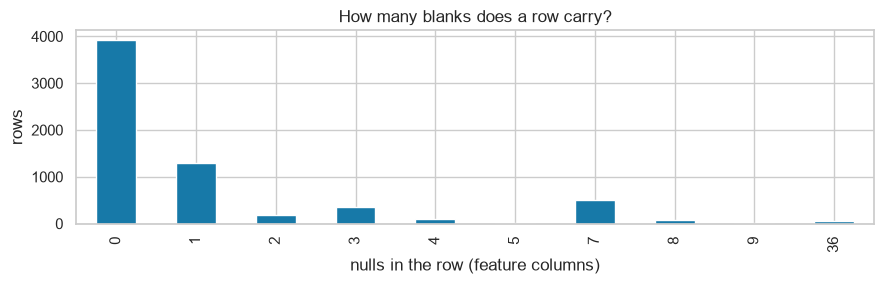

In [11]:
purchase_totals = ["Total a Pagar", "Total Bruto", "Total Liquido", "Total Imp_", "Custo"]
nulls_per_row = train_data.drop(columns=[target]).isna().sum(axis=1)

print("nulls in each purchase-total column:")
print(train_data[purchase_totals].isna().sum().to_string())
no_totals = train_data[purchase_totals].isna().all(axis=1)
print(f"\nrows where ALL of them are null: {no_totals.sum()}")

profile = pd.DataFrame({
    "rows": [no_totals.sum(), (~no_totals).sum()],
    "mean nulls per row": [nulls_per_row[no_totals].mean(), nulls_per_row[~no_totals].mean()],
    "target rate": [train_data.loc[no_totals, target].mean(),
                    train_data.loc[~no_totals, target].mean()],
    "distinct customers": [train_data.loc[no_totals, "customer_id"].nunique(),
                           train_data.loc[~no_totals, "customer_id"].nunique()],
}, index=["totals missing", "totals present"])
print()
print(profile.round(3).to_string())

fig, ax = plt.subplots(figsize=(9, 3))
nulls_per_row.value_counts().sort_index().plot(kind="bar", color=PLOT_BLUE, ax=ax)
ax.set(xlabel="nulls in the row (feature columns)", ylabel="rows",
       title="How many blanks does a row carry?")
plt.tight_layout()
plt.show()

**O que procurar.** Se os cinco totais estão vazios nas mesmas linhas e essas linhas têm muito mais vazios do que as outras, não são cinco problemas, é **um**: compras sem a parte monetária registada. Isso decide se se trata coluna a coluna ou linha a linha, e se o facto de a linha estar vazia diz algo sobre o alvo (taxa do alvo na tabela acima).

Muitos vazios nas colunas `prior_*` são **estruturais**: o desvio-padrão dos intervalos precisa de pelo menos três compras, a média do valor precisa de pelo menos uma. Um vazio explicado pela estrutura não é um defeito. Um vazio que a estrutura não explica é. O código testa essas regras como **hipóteses** (a contagem pode incluir ou não a compra atual) e mostra onde falham.

In [12]:
n_prior = train_data["prior_purchase_count"]
structural_rules = {
    "days_since_previous_purchase": n_prior == 0,
    "prior_mean_purchase_value": n_prior == 0,
    "prior_min_purchase_value": n_prior == 0,
    "prior_max_purchase_value": n_prior == 0,
    "prior_std_purchase_value": n_prior <= 1,
    "prior_mean_gap_days": n_prior <= 1,
    "prior_std_gap_days": n_prior <= 2,
}
rows = []
for column, rule in structural_rules.items():
    is_null = train_data[column].isna()
    rows.append({
        "column": column,
        "nulls": int(is_null.sum()),
        "explained by history": int((is_null & rule).sum()),
        "unexplained": int((is_null & ~rule).sum()),
        "unexplained outside the no-totals rows": int((is_null & ~rule & ~no_totals).sum()),
        "rule true but value present": int((~is_null & rule).sum()),
    })
structure = pd.DataFrame(rows).set_index("column")
print(structure.to_string())

other_nulls = train_data.drop(columns=[target]).isna().sum()
other_nulls = other_nulls[(other_nulls > 0) & ~other_nulls.index.isin(structural_rules)]
print("\nnulls in the remaining columns (no structural rule):")
print(other_nulls.sort_values(ascending=False).to_string())

                              nulls  explained by history  unexplained  unexplained outside the no-totals rows  rule true but value present
column                                                                                                                                     
days_since_previous_purchase    861                   603          258                                     193                            0
prior_mean_purchase_value       862                   603          259                                     194                            0
prior_min_purchase_value        668                   603           65                                       0                            0
prior_max_purchase_value        668                   603           65                                       0                            0
prior_std_purchase_value       1113                  1048           65                                       0                            0
prior_mean_gap_days 

**O que procurar.** A coluna *unexplained outside the no-totals rows* é a que importa: o que sobra aí é perda de dados genuína (e não ausência de histórico). Se *rule true but value present* for grande, a regra estava mal formulada (por exemplo, a contagem já inclui a compra atual) e ajusta-se o limiar antes de tirar conclusões.

### 3.2 Valores sentinela, negativos e intervalos impossíveis

In [13]:
train_hits = (train_data[numeric] >= SENTINEL_FLOOR).sum()
exact = (train_data[numeric] == 1e9).sum()
test_numeric = [c for c in numeric if c in test_data.columns]
test_hits = (test_data[test_numeric] >= SENTINEL_FLOOR).sum()

sentinels = pd.DataFrame({"train >= 1e8": train_hits, "train == 1e9": exact,
                          "test >= 1e8": test_hits}).fillna(0).astype(int)
print(sentinels[(sentinels > 0).any(axis=1)].to_string())

                           train >= 1e8  train == 1e9  test >= 1e8
prior_mean_purchase_value            16            16            2
spend_365d                           15            15            2


Os negativos já foram listados na tabela abaixo (colunas cujo domínio proíbe valores negativos).

In [14]:
non_negative = [c for c in numeric if c != "random_noise"] + [target]

summary = pd.DataFrame({
    "min": train_data[non_negative].min(),
    "negative_rows": (train_data[non_negative] < 0).sum(),
})
print(summary.round(1).to_string())

                                     min  negative_rows
Total a Pagar                        0.9              0
Total Bruto                          0.8              0
Total Liquido                        0.8              0
Total Imp_                           0.0              0
Total Portes                         0.0              0
Total Desc_ Global                   0.0              0
Total Desc_ Linha                    0.0              0
Custo                                0.0              0
N_ Detalhes                          1.0              0
invoice_count_current_purchase       1.0              0
days_since_previous_purchase        -4.0             16
customer_tenure_days                 0.0              0
prior_purchase_count                 0.0              0
prior_total_spend                    0.0              0
prior_mean_purchase_value        -2478.7             16
prior_std_purchase_value             0.0              0
prior_min_purchase_value             0.9        

**Leitura.** Esta tabela serve para **encontrar** violações; decidir o que fazer com cada uma fica para a limpeza. Nem todos os negativos são do mesmo tipo: `days_since_previous_purchase` e `prior_mean_gap_days` não podem ser negativos por definição, enquanto valores monetários negativos podem ser notas de crédito, e isso tem de se verificar contra os dados em vez de se assumir.

In [15]:
negative_prior_mean = train_data["prior_mean_purchase_value"] < 0
values = train_data.loc[negative_prior_mean, "prior_mean_purchase_value"]
print(f"{negative_prior_mean.sum()} negative rows, {values.nunique()} distinct values"
      f" (a placeholder would repeat one value)")

# prior_mean_purchase_value should equal prior_total_spend / prior_purchase_count.
# That identity says whether a negative or 1e9 is a real value or damage.
reconstructed = train_data["prior_total_spend"] / n_prior.replace(0, np.nan)
close = (train_data["prior_mean_purchase_value"] - reconstructed).abs() <= np.maximum(
    0.05, 0.01 * reconstructed.abs())
print(f"\nidentity holds within 1% on {close[reconstructed.notna() & train_data['prior_mean_purchase_value'].notna()].mean():.2%}"
      " of the rows where both sides exist")
print("reconstructed value is positive on the negative rows:",
      f"{(reconstructed[negative_prior_mean] > 0).mean():.0%}")
sentinel_mean = train_data["prior_mean_purchase_value"] >= SENTINEL_FLOOR
print("reconstructed value on the sentinel rows (median):",
      round(reconstructed[sentinel_mean].median(), 2) if sentinel_mean.any() else "n/a")

for column in ["days_since_previous_purchase", "prior_mean_gap_days"]:
    negative = train_data[column] < 0
    print(f"\n{column}: {negative.sum()} negative rows, values {sorted(train_data.loc[negative, column].unique())}")

16 negative rows, 16 distinct values (a placeholder would repeat one value)

identity holds within 1% on 98.62% of the rows where both sides exist
reconstructed value is positive on the negative rows: 100%
reconstructed value on the sentinel rows (median): 698.57

days_since_previous_purchase: 16 negative rows, values [np.float64(-4.0)]

prior_mean_gap_days: 16 negative rows, values [np.float64(-4.0)]


**O que procurar.** Se a identidade `média = gasto total / nº de compras` se verifica quase sempre e a versão reconstruída das linhas negativas ou sentinela é positiva e razoável, então o valor da coluna está **corrompido** e o valor correto é recuperável a partir de outras colunas. Isso muda a decisão no NB02 de "pôr a NaN e imputar" para "recalcular".

### 3.3 Coerência lógica entre colunas

As colunas não são independentes: as janelas rolling estão encaixadas, o mínimo não pode exceder o máximo, e os totais monetários deviam fechar. Cada linha da tabela é uma regra, e o que interessa é **quantas linhas a violam**, entre as linhas onde a regra se pode avaliar.

In [16]:
d = train_data

def check(name, ok, columns):
    valid = d[list(columns)].notna().all(axis=1)
    return {"rule": name, "rows checked": int(valid.sum()),
            "violations": int((~ok[valid]).sum())}

def close(a, b, rel=0.01, absolute=0.05):
    return (a - b).abs() <= np.maximum(absolute, rel * b.abs())

counts = [f"purchase_count_{w}d" for w in (30, 90, 180, 365)]
spends = [f"spend_{w}d" for w in (30, 90, 180, 365)]
nested = lambda cols: (d[cols[0]] <= d[cols[1]]) & (d[cols[1]] <= d[cols[2]]) & (d[cols[2]] <= d[cols[3]])
zero_iff = lambda: pd.concat([(d[s] == 0) == (d[c] == 0) for s, c in zip(spends, counts)], axis=1).all(axis=1)

rules = [
    check("purchase_count 30d <= 90d <= 180d <= 365d", nested(counts), counts),
    check("spend 30d <= 90d <= 180d <= 365d", nested(spends), spends),
    check("spend_Nd == 0 exactly when purchase_count_Nd == 0", zero_iff(), counts + spends),
    check("prior_min <= prior_mean <= prior_max",
          (d.prior_min_purchase_value <= d.prior_mean_purchase_value)
          & (d.prior_mean_purchase_value <= d.prior_max_purchase_value),
          ["prior_min_purchase_value", "prior_mean_purchase_value", "prior_max_purchase_value"]),
    check("prior_purchase_count >= purchase_count_365d",
          d.prior_purchase_count >= d.purchase_count_365d,
          ["prior_purchase_count", "purchase_count_365d"]),
    check("prior_total_spend >= spend_365d", d.prior_total_spend >= d.spend_365d,
          ["prior_total_spend", "spend_365d"]),
    check("customer_tenure_days >= days_since_previous_purchase",
          d.customer_tenure_days >= d.days_since_previous_purchase,
          ["customer_tenure_days", "days_since_previous_purchase"]),
    check("prior_mean ~ prior_total_spend / prior_purchase_count",
          close(d.prior_mean_purchase_value, d.prior_total_spend / d.prior_purchase_count.replace(0, np.nan))
          | (d.prior_purchase_count == 0),
          ["prior_mean_purchase_value", "prior_total_spend", "prior_purchase_count"]),
    check("Total a Pagar ~ Total Liquido + Total Imp_ + Total Portes",
          close(d["Total a Pagar"], d["Total Liquido"] + d["Total Imp_"] + d["Total Portes"]),
          ["Total a Pagar", "Total Liquido", "Total Imp_", "Total Portes"]),
    check("Total Liquido ~ Total Bruto - Total Desc_ Linha - Total Desc_ Global",
          close(d["Total Liquido"], d["Total Bruto"] - d["Total Desc_ Linha"] - d["Total Desc_ Global"]),
          ["Total Liquido", "Total Bruto", "Total Desc_ Linha", "Total Desc_ Global"]),
    check("Custo <= Total Liquido", d.Custo <= d["Total Liquido"], ["Custo", "Total Liquido"]),
]
consistency = pd.DataFrame(rules).set_index("rule")
consistency["% violated"] = (100 * consistency["violations"] / consistency["rows checked"]).round(2)
print(consistency.sort_values("% violated", ascending=False).to_string())

                                                                      rows checked  violations  % violated
rule                                                                                                      
Total a Pagar ~ Total Liquido + Total Imp_ + Total Portes                     6469         777       12.01
prior_min <= prior_mean <= prior_max                                          5672         220        3.88
prior_total_spend >= spend_365d                                               6274         224        3.57
prior_mean ~ prior_total_spend / prior_purchase_count                         5672          78        1.38
Custo <= Total Liquido                                                        6469          39        0.60
spend 30d <= 90d <= 180d <= 365d                                              6274          15        0.24
spend_Nd == 0 exactly when purchase_count_Nd == 0                             6274           1        0.02
purchase_count 30d <= 90d <= 180d <= 

**O que procurar.** Duas leituras diferentes. Nas regras que **têm** de ser verdade (janelas encaixadas, mínimo ≤ máximo), qualquer violação é um defeito e a lista de linhas é evidência. Nas regras **aproximadas** (os totais monetários), uma taxa de violação alta não prova erro: pode querer dizer que a relação real entre `Total Bruto`, descontos e impostos é outra. Nesse caso a regra descreve-se, não se impõe, e as colunas ficam candidatas a colinearidade (secção 6).

### 3.4 Os vazios dependem de alguma categoria?

Cruza-se a marca "a linha tem algum vazio" com cada categórica. A pergunta é se os vazios se concentram num armazém, vendedor ou zona. O alvo fica de fora de propósito: decidir a limpeza a partir do alvo deixaria o rótulo orientar o pré-processamento. `purchase_date` fica de fora porque, com mais de mil datas distintas, as contagens esperadas são mínimas e o V infla por construção.

In [17]:
blank_row = train_data.drop(columns=[target]).isna().any(axis=1)
rows = []
for column in categorical_features:
    table = pd.crosstab(blank_row, train_data[column])
    chi2, p, _, expected = chi2_contingency(table)
    rows.append({"feature": column, "levels": table.shape[1], "chi2": chi2,
                 "Cramer's V": association(table, method="cramer", correction=True),
                 "p": p, "min expected count": expected.min()})
blank_association = (pd.DataFrame(rows).set_index("feature")
                     .sort_values("Cramer's V", ascending=False))
blank_association["reliable"] = blank_association["min expected count"] >= 5
print(blank_association.round(4).to_string())

                  levels      chi2  Cramer's V       p  min expected count  reliable
feature                                                                             
transport_method      80  416.9964      0.2578  0.0000              0.3737     False
document_series        3  189.6231      0.1712  0.0000            717.7493      True
salesperson            9  181.8221      0.1702  0.0000              1.1216     False
payment_type           9  114.2150      0.1349  0.0000              1.4951     False
commercial_zone        5   38.4057      0.0771  0.0000              0.3926     False
warehouse              2    6.5184      0.0322  0.0107              7.8491      True


**O que procurar.** Só as linhas com `reliable = True` suportam conclusões. Um V baixo nessas indica que os vazios não dependem da categoria. Cuidado com a leitura: a marca "qualquer vazio" mistura vazios estruturais (clientes novos) e perdas reais, por isso uma associação fraca aqui não exclui que a perda real dependa de algo.

### 3.5 Cópia de análise

Para que as secções seguintes não sejam distorcidas pelos sentinela e pelos impossíveis, cria-se uma **cópia de análise** em que esses valores passam a NaN. `train_data` e `test_data` não são alterados, e a regra é fixa (não aprende nada de nenhum ficheiro), por isso aplica-se ao teste sem fuga.

In [18]:
def analysis_view(frame):
    """Analysis copy: sentinel and impossible values -> NaN. The raw frame is untouched."""
    out = frame.copy()
    cols = [c for c in numeric if c in out.columns]
    out[cols] = out[cols].mask(out[cols] >= SENTINEL_FLOOR)
    nonneg = [c for c in cols if c != "random_noise"]
    out[nonneg] = out[nonneg].mask(out[nonneg] < 0)
    return out

train_view = analysis_view(train_data)
test_view = analysis_view(test_data)

masked = train_view[numeric].isna().sum() - train_data[numeric].isna().sum()
masked = masked[masked > 0]
print("cells turned into NaN in the analysis copy (train):")
print(masked.to_string())

print("\nskew before and after masking, on the affected columns:")
print(pd.DataFrame({"skew raw": train_data[masked.index].skew(),
                    "skew masked": train_view[masked.index].skew()}).round(2).to_string())

cells turned into NaN in the analysis copy (train):
days_since_previous_purchase    16
prior_mean_purchase_value       32
prior_mean_gap_days             16
spend_365d                      30

skew before and after masking, on the affected columns:
                              skew raw  skew masked
days_since_previous_purchase      6.53         6.53
prior_mean_purchase_value        18.75        21.20
prior_mean_gap_days               9.30         9.31
spend_365d                       20.38        18.55


**Leitura.** É aqui que se confirma o que a tabela da secção 5 já fazia suspeitar: o skew de `spend_365d` e `prior_mean_purchase_value` estava inflacionado pelo valor sentinela e a distribuição real é muito menos extrema.

# <font color='#E8800A'>4 - Target e desequilíbrio de classes</font><a class="anchor" id="target"></a>

[Back to TOC](#toc)

In [19]:
balance = train_data[target].value_counts().sort_index()
print(balance.to_frame("rows").assign(
    share=lambda f: (f["rows"] / len(train_data)).round(4)).to_string())
print(f"\ntarget nulls: {train_data[target].isna().sum()}"
      f" | values: {sorted(train_data[target].dropna().unique())}")
print(f"always predicting the majority class scores"
      f" {balance.max() / balance.sum():.4f} accuracy and 0 recall on the other")

per_customer_rate = train_data.groupby("customer_id")[target].agg(["size", "mean"])
print(f"\nrepeat rate over rows:      {train_data[target].mean():.4f}")
print(f"repeat rate over customers: {per_customer_rate['mean'].mean():.4f}")

                     rows   share
repeat_purchase_90d              
0                    2880  0.4408
1                    3654  0.5592

target nulls: 0 | values: [np.int64(0), np.int64(1)]
always predicting the majority class scores 0.5592 accuracy and 0 recall on the other

repeat rate over rows:      0.5592
repeat rate over customers: 0.2684


**O que procurar.** O valor a guardar é a taxa da classe maioritária: é o que qualquer modelo tem de bater, e decide qual a métrica a reportar (com desequilíbrio forte, a exatidão engana). A diferença entre a taxa por linha e a taxa por cliente mostra se os clientes com muitas compras se comportam de forma diferente dos restantes, que é o que acontece quando poucos clientes pesam muito no ficheiro.

Os alvos de linhas do mesmo cliente não são independentes. A **correlação intraclasse (ICC)** mede que fração da variância do alvo é uma propriedade do cliente e não da compra: perto de 0, o alvo é quase aleatório entre clientes; perto de 1, saber o cliente basta para prever.

ICC(1) of the target across customers: 0.287


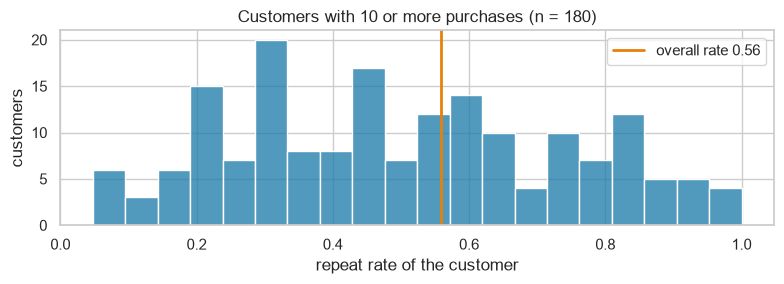

In [20]:
groups = train_data.groupby("customer_id")[target]
size, mean = groups.size(), groups.mean()
N, k = size.sum(), len(size)
grand = train_data[target].mean()
ms_between = (size * (mean - grand) ** 2).sum() / (k - 1)
ms_within = ((train_data[target] - groups.transform("mean")) ** 2).sum() / (N - k)
n0 = (N - (size ** 2).sum() / N) / (k - 1)
icc = (ms_between - ms_within) / (ms_between + (n0 - 1) * ms_within)
print(f"ICC(1) of the target across customers: {icc:.3f}")

big = per_customer_rate[per_customer_rate["size"] >= 10]
fig, ax = plt.subplots(figsize=(8, 3))
sns.histplot(big["mean"], bins=20, color=PLOT_BLUE, ax=ax)
ax.axvline(grand, color=PLOT_ORANGE, lw=2, label=f"overall rate {grand:.2f}")
ax.set(xlabel="repeat rate of the customer", ylabel="customers",
       title=f"Customers with 10 or more purchases (n = {len(big)})")
ax.legend()
plt.tight_layout()
plt.show()

**O que procurar.** Um ICC alto e uma distribuição por cliente espalhada (muitos clientes perto de 0 e perto de 1) significam que o comportamento passado do cliente é o melhor sinal e que a validação tem de impedir que o mesmo cliente apareça dos dois lados. Um ICC baixo, com os clientes concentrados em torno da taxa global, significa o contrário: o sinal está nas características da compra.

# <font color='#E8800A'>5 - Estatísticas descritivas e distribuições</font><a class="anchor" id="estatistica"></a>

[Back to TOC](#toc)

In [21]:
summary = train_data[numeric].describe().T
summary["skew"] = train_data[numeric].skew()
summary["%zeros"] = 100 * (train_data[numeric] == 0).mean()
summary = summary.sort_values("skew", ascending=False)

print(summary.round(2).to_string())

                                 count        mean          std        min      25%      50%       75%           max   skew  %zeros
Total Desc_ Global              6469.0        0.35         5.12       0.00     0.00     0.00      0.00  2.184900e+02  27.46   97.32
prior_max_purchase_value        5866.0     2946.38      5901.55       3.31   834.53  1783.24   3504.42  2.675262e+05  21.34    0.00
spend_365d                      6274.0  2396534.88  48841133.46 -159115.18   637.78  2426.60   7045.42  1.000000e+09  20.38   12.40
Total Portes                    6469.0        1.15         5.84       0.00     0.00     0.00      0.00  1.810600e+02  19.55   82.89
prior_mean_purchase_value       5672.0  2821825.32  53041566.66   -2478.66   359.56   724.90   1095.89  1.000000e+09  18.75    0.00
prior_mean_gap_days             5226.0       95.88       122.59      -4.00    42.60    68.44    113.83  3.199000e+03   9.30    0.00
prior_std_gap_days              5056.0       74.14       101.82       0.00  

**Distribuições numéricas.** Quase todas as colunas são fortemente assimétricas à direita (skew > 3 em 25 das 29), com média acima da mediana e máximos muito distantes do percentil 75, o que aponta para cauda longa e outliers nas monetárias, nas contagens e nos intervalos. Só `customer_tenure_days` (0,63) e `random_noise` (0,05, como esperado de um ruído padrão) têm distribuição próxima da simetria. `Total Desc_ Global` (97% de zeros) e `Total Portes` (83%) são quase constantes e provavelmente pouco informativas, ou úteis apenas como indicador "teve/não teve". Os zeros de `spend_*` e `purchase_count_*` (12% a 66%) refletem clientes sem atividade na janela e têm significado como vimos em cima onde ha muitos clientes que pouco compram. Em `prior_purchase_count`, `prior_total_spend` e `customer_tenure_days`, os 9,23% de zeros correspondem aos clientes na primeira compra.

**Alertas de qualidade.** O skew de `spend_365d` (20,4) e `prior_mean_purchase_value` (18,8) está inflacionado pelo valor sentinela de 1e9 e não reflete a distribuição real, por isso deve ser recalculado depois de o tratar como em falta. Persistem também os valores negativos em gastos e médias, os intervalos negativos (mínimo de -4 dias), e `spend_365d` com 195 valores em falta apesar de `purchase_count_365d` estar completo. Os `count` mostram ainda 6469 linhas por coluna contra 6534 no total, diferença de 65 linhas a esclarecer.

**Para a limpeza.** Tratar os 1e9 como NaN, investigar os negativos, manter os NaN estruturais (clientes novos) com indicador de em falta, e considerar transformação logarítmica nas colunas monetárias e de contagem. As cinco colunas monetárias da compra atual (`Total a Pagar`, `Bruto`, `Liquido`, `Imp_`, `Custo`) têm skew e escala parecidos e devem ser verificadas quanto à colinearidade. Nesta fase nada é alterado: é só diagnóstico.

### 5.1 O que o logaritmo resolve, coluna a coluna

Com os sentinela e os impossíveis fora (cópia de análise), compara-se a assimetria antes e depois de `log1p` em **todas** as colunas não negativas, em vez de escolher algumas à vista.

                                 skew  skew after log1p  % zeros  % missing  log helps
Total Desc_ Global              27.46              9.28    97.32       0.99       True
prior_max_purchase_value        21.34             -0.44     0.00      10.22       True
prior_mean_purchase_value       21.20             -0.29     0.00      13.68       True
Total Portes                    19.55              2.27    82.89       0.99       True
spend_365d                      18.55             -1.45    12.40       4.44       True
prior_mean_gap_days              9.31             -0.46     0.00      20.26       True
prior_std_gap_days               7.77             -0.17     0.02      22.62       True
days_since_previous_purchase     6.53             -0.29     0.00      13.42       True
invoice_count_current_purchase   6.44              5.00     0.00       0.99       True
Total Desc_ Linha                5.92              0.24    37.36       0.99       True
prior_min_purchase_value         5.90      

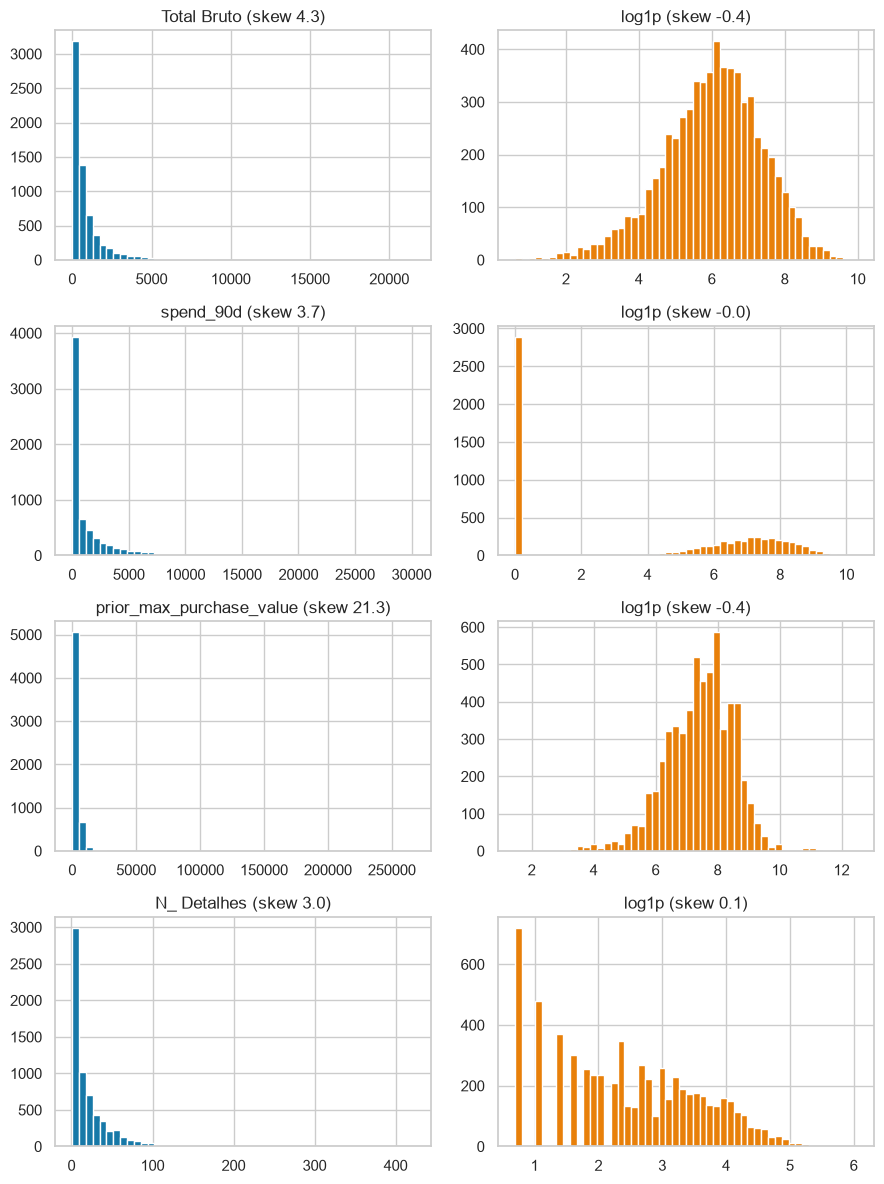

In [22]:
nonneg_cols = [c for c in numeric if c != "random_noise"]
skew_table = pd.DataFrame({
    "skew": train_view[nonneg_cols].skew(),
    "skew after log1p": np.log1p(train_view[nonneg_cols]).skew(),
    "% zeros": 100 * (train_view[nonneg_cols] == 0).mean(),
    "% missing": 100 * train_view[nonneg_cols].isna().mean(),
})
skew_table["log helps"] = skew_table["skew after log1p"].abs() < skew_table["skew"].abs()
print(skew_table.sort_values("skew", ascending=False).round(2).to_string())

cols = ["Total Bruto", "spend_90d", "prior_max_purchase_value", "N_ Detalhes"]
fig, axes = plt.subplots(len(cols), 2, figsize=(9, 3 * len(cols)))
for row, column in zip(axes, cols):
    s = train_view[column].dropna()
    row[0].hist(s, bins=50, color=PLOT_BLUE)
    row[0].set_title(f"{column} (skew {s.skew():.1f})")
    row[1].hist(np.log1p(s), bins=50, color=PLOT_ORANGE)
    row[1].set_title(f"log1p (skew {np.log1p(s).skew():.1f})")
plt.tight_layout()
plt.show()

**O que procurar.** `log helps = True` com um skew final perto de 0 confirma que a cauda é longa mas contínua, e que a transformação a comprime. Onde a coluna tem muitos zeros (`% zeros` alto), o log não cria simetria: o zero fica como pico e a coluna passa a ser, na prática, "fez / não fez" mais uma quantidade. Esses casos merecem um indicador próprio no NB02.

### 5.2 Variáveis categóricas

O que importa em cada categórica é quantos níveis tem, se um domina, e quantos são tão raros que nenhum modelo os aprende.

                  levels  % missing                    top level  top share %  levels under 1% of rows
transport_method      80       3.99   Maybe Tomorrow Delivery 72        17.84                       59
payment_type           9       3.98     Maybe Tomorrow Payment 7        72.76                        5
salesperson            9       3.96             VLOOKUP Master 1        64.61                        4
commercial_zone        5       0.99  Decorative Dashboard Zone 4        96.77                        3
document_series        3       0.99              Ctrl Z Series 2        42.32                        0
warehouse              2       3.98      Final Excel Warehouse 1        99.67                        1


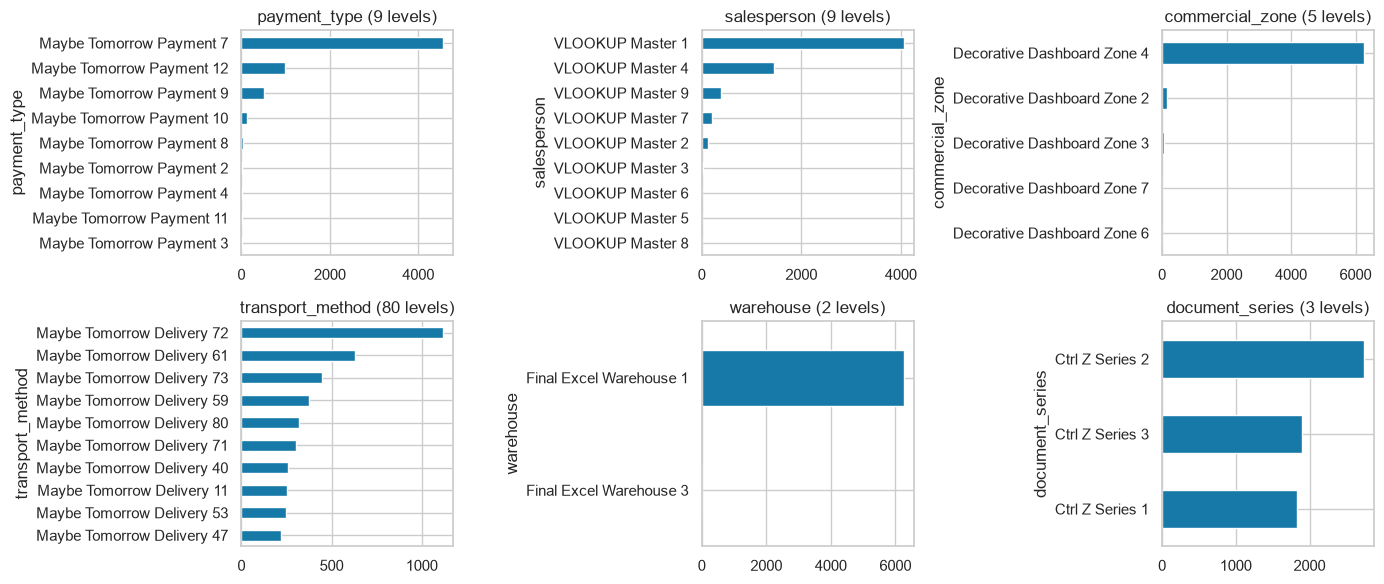

In [23]:
def top_level(s):
    return s.value_counts().index[0]

cat_profile = pd.DataFrame({
    "levels": train_data[categorical_features].nunique(),
    "% missing": 100 * train_data[categorical_features].isna().mean(),
    "top level": train_data[categorical_features].apply(top_level),
    "top share %": 100 * train_data[categorical_features].apply(
        lambda s: s.value_counts(normalize=True).iloc[0]),
    "levels under 1% of rows": train_data[categorical_features].apply(
        lambda s: int((s.value_counts(normalize=True) < 0.01).sum())),
}).sort_values("levels", ascending=False)
print(cat_profile.round(2).to_string())

fig, axes = plt.subplots(2, 3, figsize=(14, 6))
for ax, column in zip(axes.ravel(), categorical_features):
    train_data[column].value_counts().head(10).sort_values().plot(
        kind="barh", color=PLOT_BLUE, ax=ax)
    ax.set_title(f"{column} ({train_data[column].nunique()} levels)")
plt.tight_layout()
plt.show()

**O que procurar.** Um nível dominante (`top share %` alto) deixa a coluna quase constante. Muitos níveis abaixo de 1% das linhas em colunas como `salesperson` ou `commercial_zone` significam que o one-hot cria colunas com poucos exemplos cada, e que agrupar os raros num nível "outros" é uma decisão a medir no NB02.

# <font color='#E8800A'>6 - Relações com o target</font><a class="anchor" id="relacao"></a>

[Back to TOC](#toc)

Cada análise desta secção responde a uma pergunta diferente: **que variáveis separam quem volta de quem não volta** (6.1 a 6.3), e **que variáveis dizem o mesmo umas das outras** (6.4 e 6.5). Todas usam a cópia de análise, e as linhas do mesmo cliente não são independentes, pelo que os p-values são optimistas e as magnitudes (AUC, V) são mais fiáveis do que eles.

### 6.1 Poder de cada variável numérica, sozinha

A **AUC** de uma variável isolada diz com que frequência uma compra com alvo 1 tem valor mais alto do que uma com alvo 0: 0,5 é sem informação, 1 e 0 são separação perfeita (a direção distingue-se pelo lado de 0,5). `random_noise` é o **padrão de comparação**: o que não se distingue dele, não separa as classes.

                                n used     AUC  Spearman    edge
purchase_count_365d             6469.0  0.7529    0.4370  0.2529
prior_mean_gap_days             5210.0  0.2525   -0.4204  0.2475
purchase_count_180d             6469.0  0.7323    0.4061  0.2323
spend_365d                      6244.0  0.7251    0.3875  0.2251
purchase_count_90d              6469.0  0.7155    0.3928  0.2155
spend_180d                      6469.0  0.7138    0.3695  0.2138
prior_purchase_count            6469.0  0.7008    0.3456  0.2008
spend_90d                       6469.0  0.6993    0.3591  0.1993
prior_total_spend               6469.0  0.6928    0.3316  0.1928
prior_std_gap_days              5056.0  0.3131   -0.3151  0.1869
days_since_previous_purchase    5657.0  0.3153   -0.3153  0.1847
prior_max_purchase_value        5866.0  0.6475    0.2519  0.1475
prior_min_purchase_value        5866.0  0.3621   -0.2355  0.1379
purchase_count_30d              6469.0  0.6260    0.2612  0.1260
spend_30d                

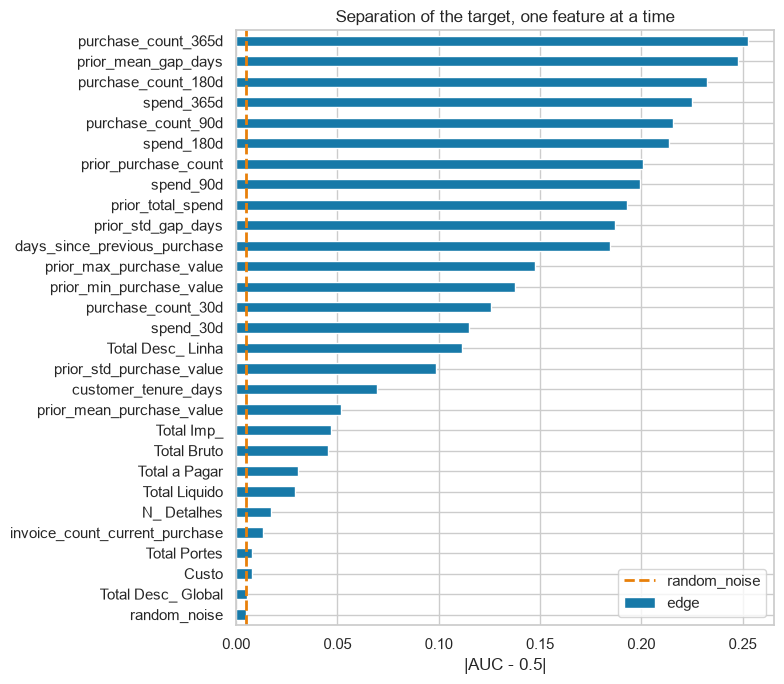

In [24]:
def single_feature_auc(frame, columns, y):
    out = {}
    for column in columns:
        values = frame[column]
        ok = values.notna()
        if ok.sum() < 50 or y[ok].nunique() < 2:
            continue
        out[column] = {"n used": int(ok.sum()),
                       "AUC": roc_auc_score(y[ok], values[ok]),
                       "Spearman": spearmanr(values[ok], y[ok]).statistic}
    return pd.DataFrame(out).T

y = train_data[target]
auc_table = single_feature_auc(train_view, numeric, y)
auc_table["edge"] = (auc_table["AUC"] - 0.5).abs()
auc_table = auc_table.sort_values("edge", ascending=False)
noise_edge = auc_table.loc["random_noise", "edge"]
print(auc_table.round(4).to_string())
print(f"\nrandom_noise edge: {noise_edge:.4f}")
print("not distinguishable from random_noise:",
      list(auc_table.index[auc_table["edge"] <= noise_edge]))

fig, ax = plt.subplots(figsize=(8, 7))
auc_table["edge"].sort_values().plot(kind="barh", color=PLOT_BLUE, ax=ax)
ax.axvline(noise_edge, color=PLOT_ORANGE, lw=2, ls="--", label="random_noise")
ax.set(xlabel="|AUC - 0.5|", title="Separation of the target, one feature at a time")
ax.legend()
plt.tight_layout()
plt.show()

**O que procurar.** As variáveis acima da linha laranja têm sinal individual. As abaixo (ou colada a ela) podem ainda ser úteis **em combinação**, que a AUC isolada não vê, mas deixam de ser candidatas óbvias. Duas ressalvas: a AUC ignora a direção (usar `Spearman` para o sinal) e uma relação não monótona (por exemplo, voltar mais para gastos médios do que para extremos) pode dar AUC próxima de 0,5 e ser relevante.

### 6.2 Forma da relação

A AUC resume numa única cifra; a **taxa do alvo por intervalo** mostra a forma. Os intervalos são quantis, e a categoria `missing` mostra se o vazio, só por si, informa.

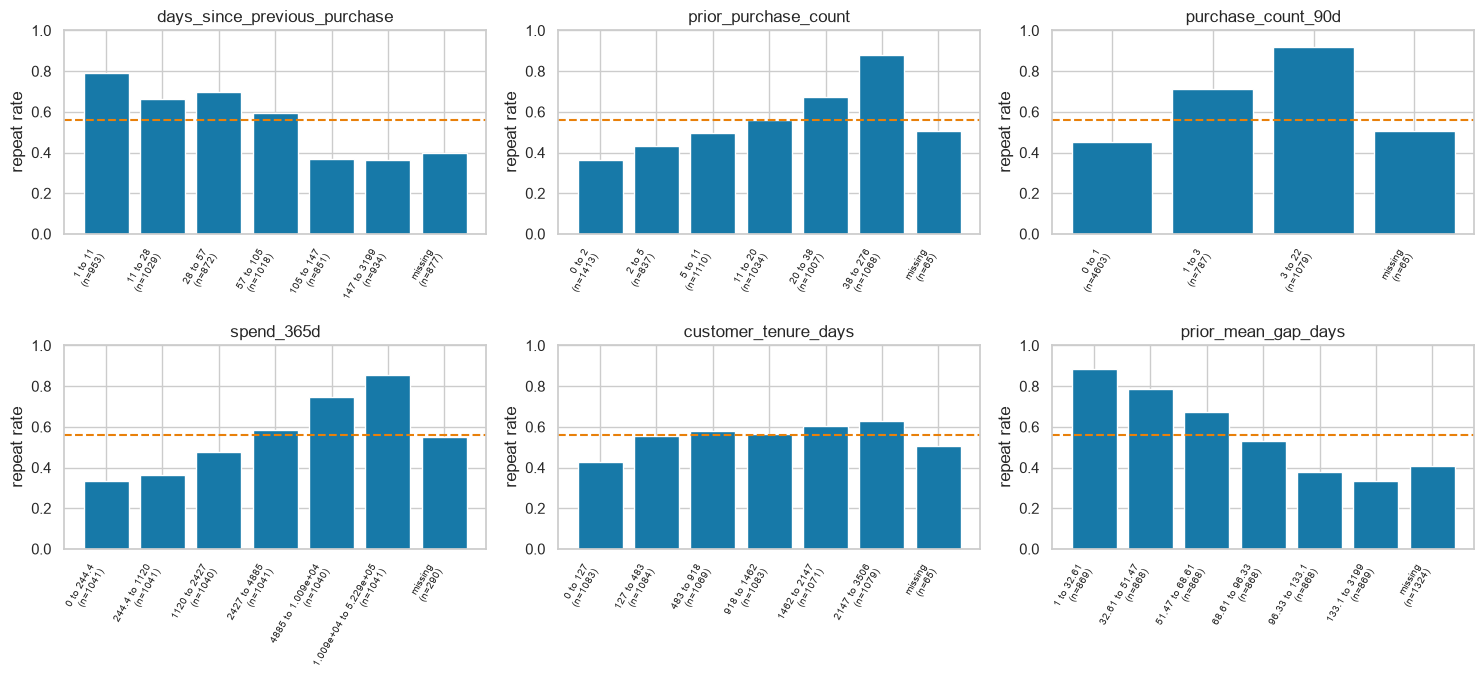

In [25]:
def rate_by_bin(frame, column, y, q=6):
    s = frame[column]
    binned, edges = pd.qcut(s, q=q, labels=False, retbins=True, duplicates="drop")
    labels = {i: f"{edges[i]:.4g} to {edges[i + 1]:.4g}" for i in range(len(edges) - 1)}
    order = [labels[i] for i in range(len(labels))]
    if s.isna().any():
        order.append("missing")
    names = binned.map(labels).fillna("missing")
    out = pd.DataFrame({"bin": names, "y": y}).groupby("bin")["y"].agg(["mean", "size"])
    return out.reindex(order)

key_features = ["days_since_previous_purchase", "prior_purchase_count",
                "purchase_count_90d", "spend_365d",
                "customer_tenure_days", "prior_mean_gap_days"]
base_rate = y.mean()
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, column in zip(axes.ravel(), key_features):
    table = rate_by_bin(train_view, column, y)
    ax.bar(range(len(table)), table["mean"], color=PLOT_BLUE)
    ax.axhline(base_rate, color=PLOT_ORANGE, ls="--", lw=1.5)
    ax.set_xticks(range(len(table)))
    ax.set_xticklabels([f"{b}\n(n={n})" for b, n in zip(table.index, table["size"])],
                       rotation=60, ha="right", fontsize=7)
    ax.set(title=column, ylim=(0, 1), ylabel="repeat rate")
plt.tight_layout()
plt.show()

**O que procurar.** Uma escada monótona confirma uma relação simples (e que uma transformação monótona como o log chega). Uma forma em U ou com patamar pede binning ou modelos de árvore. Uma barra `missing` muito diferente da taxa global (linha laranja) diz que o vazio **é** informação, e que o indicador de em falta, previsto na secção 10, tem valor.

### 6.3 Variáveis categóricas

Para cada categórica mede-se a força da associação com o alvo (V de Cramér, comparável entre colunas) e vê-se o nível que mais se afasta da taxa global. Com `Bonferroni` porque são vários testes em simultâneo.

In [26]:
rows = []
for column in categorical_features:
    table = pd.crosstab(train_data[column], train_data[target])
    chi2, p, _, expected = chi2_contingency(table)
    rows.append({"feature": column, "levels": table.shape[0],
                 "Cramer's V": association(table, method="cramer", correction=True),
                 "p": p, "min expected count": expected.min()})
cat_target = pd.DataFrame(rows).set_index("feature").sort_values("Cramer's V", ascending=False)
cat_target["reliable"] = cat_target["min expected count"] >= 5
cat_target["significant (Bonferroni)"] = cat_target["p"] < 0.05 / len(cat_target)
print(cat_target.round(4).to_string())

for column in [c for c in categorical_features if train_data[c].nunique() <= 6]:
    print(f"\n{column}")
    print(train_data.groupby(column)[target].agg(rate="mean", rows="size").round(3).to_string())

wide = [c for c in categorical_features if train_data[c].nunique() > 6]
for column in wide:
    by_level = train_data.groupby(column)[target].agg(rate="mean", rows="size")
    by_level = by_level[by_level["rows"] >= 50].sort_values("rate")
    print(f"\n{column}: lowest and highest rate among levels with 50+ rows")
    print(pd.concat([by_level.head(3), by_level.tail(3)]).round(3).to_string())

                  levels  Cramer's V       p  min expected count  reliable  significant (Bonferroni)
feature                                                                                             
transport_method      80      0.2899  0.0000              0.4400     False                      True
payment_type           9      0.2376  0.0000              1.7616     False                      True
salesperson            9      0.2033  0.0000              1.3243     False                      True
commercial_zone        5      0.0638  0.0000              0.4403     False                      True
warehouse              2      0.0266  0.0348              9.2950      True                     False
document_series        3      0.0029  0.9727            804.7834      True                     False

commercial_zone
                              rate  rows
commercial_zone                         
Decorative Dashboard Zone 2  0.411   151
Decorative Dashboard Zone 3  0.357    56
Decorative 

**O que procurar.** Um V baixo, mesmo "significativo", é um efeito pequeno: com 6500 linhas quase tudo é significativo. O V é o número a comparar entre colunas, e `reliable` indica se o teste tem contagens suficientes. Num nível raro, uma taxa extrema com poucas linhas é ruído, o que é a razão do filtro de 50 linhas.

### 6.4 Colinearidade entre numéricas

A correlação de **Spearman** (por postos, imune à cauda longa) ordenada por agrupamento hierárquico: colunas que dizem o mesmo ficam juntas, formando blocos visíveis.

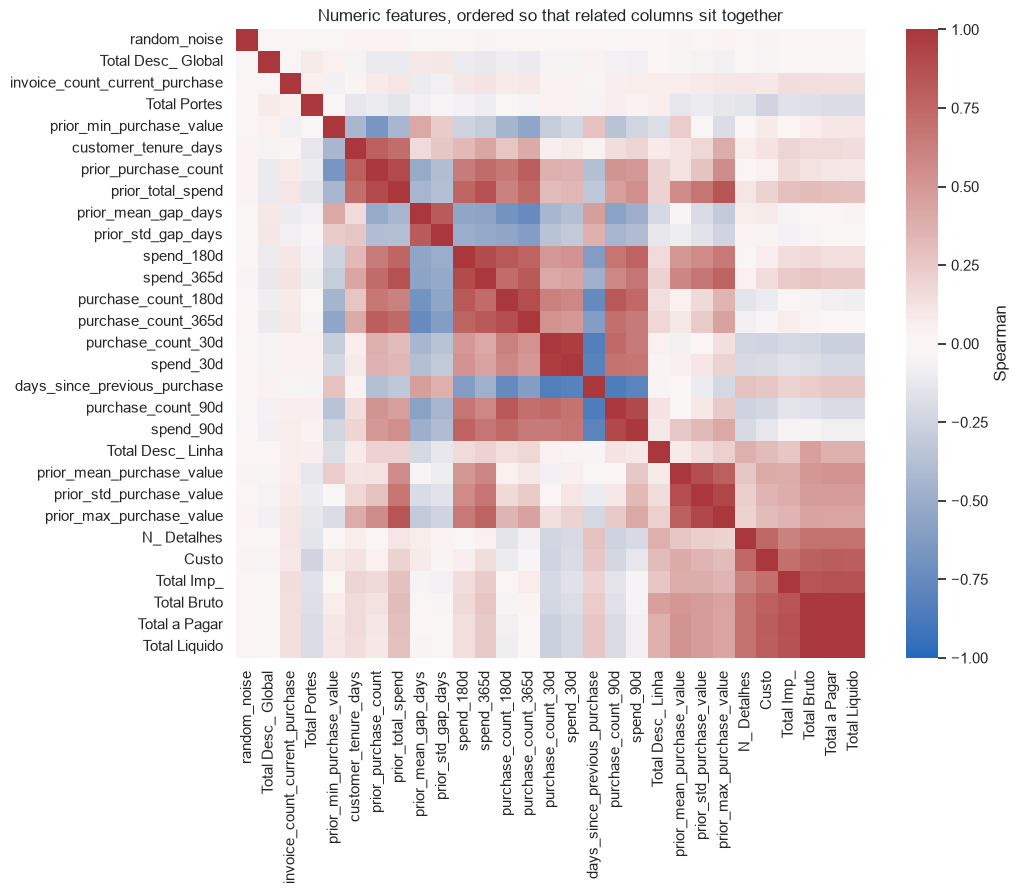

7 pairs with |rho| >= 0.9
                       a                        b   rho
           Total a Pagar            Total Liquido 1.000
             Total Bruto            Total Liquido 0.991
           Total a Pagar              Total Bruto 0.991
      purchase_count_30d                spend_30d 0.965
prior_std_purchase_value prior_max_purchase_value 0.923
      purchase_count_90d                spend_90d 0.909
    prior_purchase_count        prior_total_spend 0.903

largest |rho| involving random_noise: 0.035


In [27]:
corr = train_view[numeric].corr(method="spearman")
distance = (1 - corr.abs().fillna(0)).to_numpy(copy=True)
np.fill_diagonal(distance, 0)
order = leaves_list(linkage(squareform(distance, checks=False), method="average"))
ordered = corr.iloc[order, order]

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(ordered, vmin=-1, vmax=1, cmap="vlag", square=True,
            cbar_kws={"label": "Spearman"}, ax=ax)
ax.set_title("Numeric features, ordered so that related columns sit together")
plt.tight_layout()
plt.show()

pairs = (corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1))
         .stack().rename("rho").reset_index())
pairs.columns = ["a", "b", "rho"]
strong = pairs[pairs["rho"].abs() >= 0.9].sort_values("rho", key=abs, ascending=False)
print(f"{len(strong)} pairs with |rho| >= 0.9")
print(strong.round(3).to_string(index=False))
print(f"\nlargest |rho| involving random_noise: {corr['random_noise'].drop('random_noise').abs().max():.3f}")

**O que procurar.** Os blocos esperados são o monetário da compra atual, as janelas rolling encaixadas e as estatísticas `prior_*`. Colunas com |ρ| ≥ 0,9 trazem quase a mesma informação: num modelo linear desestabilizam os coeficientes, e em modelos de árvore dividem a importância. O NB02 decide se mantém uma por bloco ou as combina em rácios. A correlação máxima de `random_noise` com as outras é o piso do que se pode chamar "ruído".

### 6.5 Associação entre categóricas

Duas categóricas fortemente associadas dizem a mesma coisa (por exemplo, um armazém que só usa uma série documental).

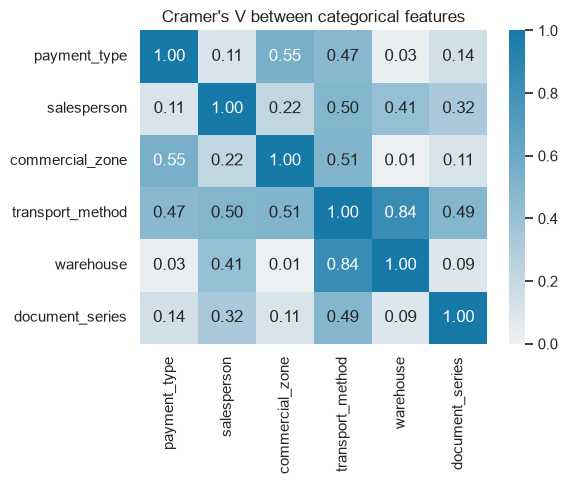

In [28]:
cats = categorical_features
cramer = pd.DataFrame(1.0, index=cats, columns=cats)
for a in cats:
    for b in cats:
        if a != b:
            cramer.loc[a, b] = association(pd.crosstab(train_data[a], train_data[b]),
                                           method="cramer", correction=True)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cramer, vmin=0, vmax=1, annot=True, fmt=".2f",
            cmap=sns.light_palette(PLOT_BLUE, as_cmap=True), ax=ax)
ax.set_title("Cramer's V between categorical features")
plt.tight_layout()
plt.show()

**O que procurar.** Valores acima de ~0,5 entre duas colunas indicam redundância. `salesperson` e `commercial_zone`, com muitos níveis, tendem a dar V elevado entre si por construção (um vendedor trabalha numa zona), o que justifica manter uma só ou testar a perda.

# <font color='#E8800A'>7 - Estrutura temporal, repetição de clientes e deriva train vs. test</font><a class="anchor" id="temporal"></a>

[Back to TOC](#toc)

### 7.1 A data

`purchase_date` está guardada como texto. Converte-se numa **série local** (as colunas originais não são alteradas) para ver o intervalo coberto, e quanto do teste cai depois do fim do treino, que é o que distingue um corte temporal de uma partição aleatória.

In [29]:
train_date = pd.to_datetime(train_data[date_col], errors="coerce")
test_date = pd.to_datetime(test_data[date_col], errors="coerce")
print(f"unparsable dates: train {train_date.isna().sum()}, test {test_date.isna().sum()}")
print(f"train: {train_date.min():%Y-%m-%d} to {train_date.max():%Y-%m-%d}"
      f" ({train_date.nunique()} distinct dates)")
print(f"test:  {test_date.min():%Y-%m-%d} to {test_date.max():%Y-%m-%d}"
      f" ({test_date.nunique()} distinct dates)")
print(f"share of test rows dated after the last train date: {(test_date > train_date.max()).mean():.2%}")

seen_rows = test_data["customer_id"].isin(train_data["customer_id"]).mean()
seen_customers = (test_data["customer_id"].drop_duplicates()
                  .isin(train_data["customer_id"]).mean())
print(f"test rows whose customer is in train: {seen_rows:.2%}")
print(f"distinct test customers present in train: {seen_customers:.2%}")

unparsable dates: train 65, test 0
train: 2015-07-11 to 2025-02-15 (1492 distinct dates)
test:  2025-05-24 to 2026-10-06 (223 distinct dates)
share of test rows dated after the last train date: 100.00%
test rows whose customer is in train: 94.52%
distinct test customers present in train: 89.32%


**O que procurar.** Se quase todo o teste vem **depois** do treino e os clientes são os mesmos, o problema é de previsão no futuro, e a validação deve imitar isso (treino no passado, validação no mais recente). Se as datas se sobrepõem, uma partição aleatória por cliente é defensável. Qualquer data não convertida seria um defeito a tratar.

### 7.2 Volume e taxa do alvo ao longo do tempo

A linha a tracejado marca os últimos 90 dias do treino. O alvo olha 90 dias para a frente, por isso as compras aí têm a janela incompleta, e se a taxa cai nessa zona é um artefacto da observação, não um comportamento.

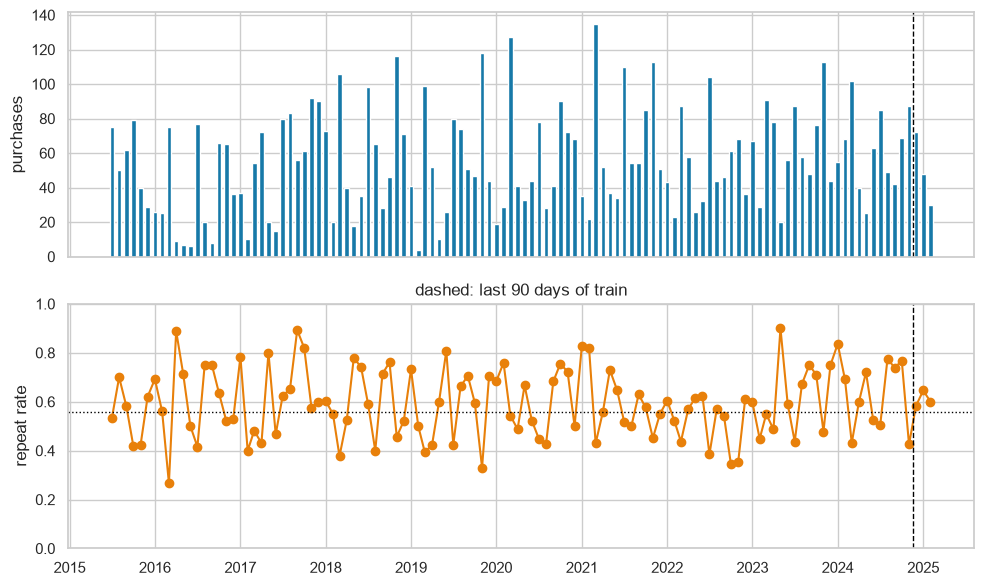

In [30]:
month = train_date.dt.to_period("M")
monthly = pd.DataFrame({"rows": month.value_counts().sort_index(),
                        "target rate": train_data[target].groupby(month).mean()})
x = monthly.index.to_timestamp()
cutoff = train_date.max() - pd.Timedelta(days=90)

fig, (top, bottom) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
top.bar(x, monthly["rows"], width=20, color=PLOT_BLUE)
top.set_ylabel("purchases")
bottom.plot(x, monthly["target rate"], marker="o", color=PLOT_ORANGE)
bottom.axhline(train_data[target].mean(), color="black", ls=":", lw=1)
for ax in (top, bottom):
    ax.axvline(cutoff, color="black", ls="--", lw=1)
bottom.set(ylabel="repeat rate", ylim=(0, 1), title="dashed: last 90 days of train")
plt.tight_layout()
plt.show()

**O que procurar.** Uma tendência na taxa (de subida ou descida) indica que o comportamento muda com o tempo e que a data é relevante para a validação. Uma queda só na zona tracejada é censura à direita. Meses com poucos registos tornam a taxa instável, e é para isso que serve o gráfico de cima.

### 7.3 O alvo está escrito na sequência das datas?

`repeat_purchase_90d` diz se o cliente volta em 90 dias. Dentro do treino, essa resposta pode ler-se na **compra seguinte do mesmo cliente**: se a data seguinte está a menos de 90 dias, o alvo é 1. Convém verificar duas coisas: se as datas e `days_since_previous_purchase` concordam, e se o alvo se reconstrói só com as datas.

In [31]:
seq = (pd.DataFrame({"customer_id": train_data["customer_id"], "date": train_date,
                     "ID": train_data["ID"],
                     "reported_gap": train_data["days_since_previous_purchase"],
                     target: train_data[target]})
       .sort_values(["customer_id", "date", "ID"]))
by_customer = seq.groupby("customer_id")["date"]
seq["gap_from_dates"] = (seq["date"] - by_customer.shift(1)).dt.days
seq["next_gap"] = (by_customer.shift(-1) - seq["date"]).dt.days

both = seq["gap_from_dates"].notna() & seq["reported_gap"].notna()
difference = (seq.loc[both, "gap_from_dates"] - seq.loc[both, "reported_gap"])
print(f"rows where both gaps exist: {both.sum()}")
print(f"reported gap equals the gap between dates: {(difference == 0).mean():.2%}")
print("most common differences:", difference.value_counts().head(5).to_dict())

window_complete = seq["date"] <= train_date.max() - pd.Timedelta(days=90)
rules = {"next purchase within 90 days": (seq["next_gap"] <= 90),
         "next purchase 1 to 90 days later": (seq["next_gap"] >= 1) & (seq["next_gap"] <= 90)}
rebuilt = pd.DataFrame({
    name: {"all rows": (rule.astype(int) == seq[target]).mean(),
           "rows with a full 90-day window":
               (rule.astype(int)[window_complete] == seq[target][window_complete]).mean()}
    for name, rule in rules.items()}).T
print("\nshare of rows where the date-based rule reproduces the target:")
print(rebuilt.round(4).to_string())

rows where both gaps exist: 5670
reported gap equals the gap between dates: 98.82%
most common differences: {0.0: 5603, 7.0: 3, 1.0: 2, 105.0: 2, 59.0: 2}

share of rows where the date-based rule reproduces the target:
                                  all rows  rows with a full 90-day window
next purchase within 90 days        0.9864                          0.9975
next purchase 1 to 90 days later    0.9864                          0.9975


**O que procurar.** Se a regra "compra seguinte a menos de 90 dias" reproduz o alvo em quase 100% das linhas com janela completa, o alvo é **determinístico a partir das datas**. Isto tem duas consequências. Primeiro, qualquer variável construída a partir da compra seguinte (por exemplo, o intervalo da linha seguinte) é uma fuga direta. Segundo, as taxas históricas do alvo por cliente só se podem usar com linhas **anteriores** à janela de 90 dias, senão contêm o futuro. Se a concordância for menor nas linhas sem janela completa, é a censura a aparecer. Se `reported_gap` não bate com o intervalo das datas, vale perceber porquê antes de confiar nas variáveis de recência.

### 7.4 Deriva entre treino e teste

O teste só se usa para **comparar distribuições**, nunca para ajustar nada. Nas numéricas mede-se a distância de Kolmogorov-Smirnov (0 = iguais, 1 = disjuntas) e a diferença na fração de vazios; nas categóricas, a distância de variação total e os níveis que só existem no teste.

In [32]:
drift_cols = [c for c in numeric if c in test_view.columns and test_view[c].notna().any()]
ks = {c: ks_2samp(train_view[c].dropna(), test_view[c].dropna()) for c in drift_cols}
num_drift = pd.DataFrame({
    "KS": {c: r.statistic for c, r in ks.items()},
    "p": {c: r.pvalue for c, r in ks.items()},
    "% missing train": 100 * train_view[drift_cols].isna().mean(),
    "% missing test": 100 * test_view[drift_cols].isna().mean(),
}).sort_values("KS", ascending=False)
print(num_drift.round(4).to_string())

def tvd(a, b):
    pa, pb = a.value_counts(normalize=True), b.value_counts(normalize=True)
    index = pa.index.union(pb.index)
    return 0.5 * (pa.reindex(index, fill_value=0) - pb.reindex(index, fill_value=0)).abs().sum()

cat_drift = pd.DataFrame({
    column: {"TVD": tvd(train_data[column], test_data[column]),
             "levels only in test": len(set(test_data[column].dropna()) - set(train_data[column].dropna())),
             "% test rows in unseen levels": 100 * (test_data[column].notna()
                 & ~test_data[column].isin(train_data[column].dropna())).mean()}
    for column in categorical_features}).T.sort_values("TVD", ascending=False)
print()
print(cat_drift.round(4).to_string())

                                    KS       p  % missing train  % missing test
customer_tenure_days            0.4620  0.0000           0.9948          0.0000
prior_total_spend               0.3185  0.0000           0.9948          0.0000
prior_purchase_count            0.3134  0.0000           0.9948          0.0000
prior_max_purchase_value        0.2558  0.0000          10.2234          2.2312
Total Desc_ Linha               0.2431  0.0000           0.9948          0.0000
spend_365d                      0.2099  0.0000           4.4383          3.4483
prior_mean_purchase_value       0.1820  0.0000          13.6823          5.6795
prior_min_purchase_value        0.1804  0.0000          10.2234          2.2312
prior_std_purchase_value        0.1539  0.0000          17.0340          4.6653
prior_std_gap_days              0.1507  0.0000          22.6201          6.9980
spend_180d                      0.1488  0.0000           0.9948          0.0000
Total Bruto                     0.1402  

**O que procurar.** Deriva forte em colunas **de tempo** (`customer_tenure_days`, `prior_purchase_count`, janelas rolling) é esperada se o teste é posterior: o cliente é mais antigo e tem mais histórico. Não é um defeito, mas obriga a validar em corte temporal. Deriva em colunas que **não** dependem do tempo (por exemplo, categóricas) seria um sinal de que o teste vem de outra população. Níveis só presentes no teste não têm exemplos no treino, e o NB02 tem de os agrupar. Um `% missing` diferente entre treino e teste indica que a recolha de dados mudou.

# <font color='#E8800A'>8 - Análise crítica de identificadores e ruído</font><a class="anchor" id="analise"></a>

[Back to TOC](#toc)

Um identificador não devia dizer nada sobre o alvo, e `random_noise` também não. Se algum dos dois dissesse, o desenho do ficheiro tem um problema (ou uma fuga), e é melhor descobri-lo agora.

**Identificadores.** Procura-se informação escondida na própria ordem: se o `ID` cresce com a data, ou se separa as classes.

In [33]:
id_date = pd.DataFrame({"ID": train_data["ID"], "date": train_date}).dropna()
print("ID unique:", train_data["ID"].is_unique,
      "| monotonic increasing:", train_data["ID"].is_monotonic_increasing)
print(f"ID range train {train_data['ID'].min()}-{train_data['ID'].max()},"
      f" test {test_data['ID'].min()}-{test_data['ID'].max()}")
print(f"Spearman between ID and date: {spearmanr(id_date['ID'], id_date['date'].map(pd.Timestamp.toordinal)).statistic:.3f}")

candidates = pd.DataFrame({"ID": train_data["ID"], "customer_id": train_data["customer_id"],
                           "random_noise": train_view["random_noise"]})
id_auc = single_feature_auc(candidates, list(candidates.columns), y)
id_auc["edge"] = (id_auc["AUC"] - 0.5).abs()
print()
print(id_auc.round(4).to_string())

ID unique: True | monotonic increasing: True
ID range train 10000000-10007674, test 10000006-10007675
Spearman between ID and date: 0.011

              n used     AUC  Spearman    edge
ID            6534.0  0.5070    0.0121  0.0070
customer_id   6534.0  0.4322   -0.1166  0.0678
random_noise  6469.0  0.4952   -0.0082  0.0048


**O que procurar.** Uma correlação alta entre `ID` e data significa que o `ID` é um **relógio** disfarçado: usado como feature, deixa o modelo aprender o tempo. Uma AUC afastada de 0,5 no `ID` ou `customer_id` indicaria que a numeração codifica algo sobre o alvo. Para `customer_id`, mesmo uma AUC próxima de 0,5 não resolve o problema de fundo (o modelo decorar clientes), que é o que a secção 4 e a 7 já tratam.

**Ruído.** `random_noise` deve ser independente de tudo. Verifica-se que se comporta como uma normal padrão, que não se relaciona com o alvo nem com as outras colunas, e que é igual no treino e no teste.

In [34]:
noise = train_view["random_noise"].dropna()
z = (noise - noise.mean()) / noise.std(ddof=0)
print(f"mean {noise.mean():.3f}, std {noise.std():.3f}, skew {noise.skew():.3f}")
print(f"KS against N(0,1): statistic {kstest(z, 'norm').statistic:.4f}, p {kstest(z, 'norm').pvalue:.3f}")
print(f"AUC against the target: {id_auc.loc['random_noise', 'AUC']:.4f}")
print(f"largest |Spearman| with any other numeric column: {corr['random_noise'].drop('random_noise').abs().max():.3f}")
print(f"train vs test KS: {num_drift.loc['random_noise', 'KS']:.4f} (p {num_drift.loc['random_noise', 'p']:.3f})")

above = auc_table.drop("random_noise")
print(f"\nreal numeric features with more separation than random_noise: "
      f"{int((above['edge'] > noise_edge).sum())} of {len(above)}")

mean -0.022, std 1.001, skew 0.054
KS against N(0,1): statistic 0.0141, p 0.149
AUC against the target: 0.4952
largest |Spearman| with any other numeric column: 0.035
train vs test KS: 0.0404 (p 0.119)

real numeric features with more separation than random_noise: 28 of 28


**O que procurar.** Todos os números perto do esperado para uma normal independente (média 0, desvio 1, AUC e correlações perto de 0) confirmam que `random_noise` é de facto ruído e serve de **piso**: nenhuma variável real deve ser mantida só porque aparenta ter sinal ao nível dele. A última linha conta quantas variáveis reais o superam.

# <font color='#E8800A'>9 - Ligação com o clientes.csv</font><a class="anchor" id="clientes"></a>

[Back to TOC](#toc)

O `clientes.csv` só interessa se (a) cobre os clientes do treino e do teste, (b) a chave é única, para a ligação não duplicar linhas, e (c) as colunas que traz **não contêm o futuro**. Um atributo calculado com todo o período (por exemplo, um total de compras) incluiria compras posteriores à linha, e seria fuga. Esta secção inspeciona o ficheiro e testa essas três coisas **sem alterar** nenhum dos dois.

### 9.1 Estrutura

In [42]:
key = "customer_id"
assert key in clientes_data.columns, f"'{key}' not in clientes.csv: {list(clientes_data.columns)}"

print(clientes_data.shape)
print(clientes_data.head(3).to_string())
print()
print(clientes_data.dtypes.to_string())
null_counts = clientes_data.isna().sum()
print("\nnulls:", null_counts[null_counts > 0].to_dict() or "none")
print(f"key unique: {clientes_data[key].is_unique} | null keys: {clientes_data[key].isna().sum()}"
      f" | duplicated rows: {clientes_data.duplicated().sum()}")

(1143, 13)
   customer_id                        country_or_region               commercial_region                             island                                     municipality                           city                             postal_area                              postal_code                             street                              address  customer_type                      company_name  customer_since_year
0       842570  Country CT11: Land of The Final Version  Region RG37: We Will See Later                                NaN                                              NaN  City CY417: Missing Cell Port                                     NaN  Postal code PC828: #REF! Delivery Route                                NaN  Address AD1120: Cell Without a Home            NaN   Excel Is Not A Database Ltd 150                 2018
1       770941   Country CT9: Land of The Final Version                             NaN                                NaN               

### 9.2 Cobertura e efeito da ligação

In [36]:
cl_keys = set(clientes_data[key].dropna())
coverage = pd.Series({
    "train customers found in clientes": np.mean([k in cl_keys for k in train_data[key].drop_duplicates()]),
    "train rows with a match": train_data[key].isin(cl_keys).mean(),
    "test rows with a match": test_data[key].isin(cl_keys).mean(),
    "clientes rows never seen in train or test":
        1 - np.mean([k in set(train_data[key]) | set(test_data[key]) for k in clientes_data[key].dropna()]),
}).round(4)
print(coverage.to_string())

try:
    train_merged = train_data.merge(clientes_data, on=key, how="left", validate="m:1",
                                    suffixes=("", "_cli"))
    print(f"\nmerge keeps the row count: {len(train_merged) == len(train_data)}"
          f" ({len(train_data)} -> {len(train_merged)})")
except Exception as error:
    train_merged = None
    print("\nmerge failed:", error)

if train_merged is not None:
    matched = train_data[key].isin(cl_keys)
    print(f"repeat rate with a match / without: "
          f"{train_data.loc[matched, target].mean():.3f} / "
          f"{train_data.loc[~matched, target].mean() if (~matched).any() else float('nan'):.3f}")

train customers found in clientes            1.0000
train rows with a match                      1.0000
test rows with a match                       1.0000
clientes rows never seen in train or test    0.4471

merge keeps the row count: True (6534 -> 6534)
repeat rate with a match / without: 0.559 / nan


**O que procurar.** Cobertura de 100% e chave única: a ligação é segura e pode ser feita no NB02 com `validate="m:1"`. Clientes sem correspondência precisam de uma regra (indicador de em falta). Uma chave duplicada faria o `merge` multiplicar linhas e inflacionaria o treino.

### 9.3 O que as colunas do clientes.csv trazem

Cada coluna é classificada (numérica, data ou categórica) e medida contra o alvo, como na secção 6. Para as numéricas faz-se ainda um teste contra **agregados do próprio treino por cliente**: se uma coluna acompanha o número de compras do cliente no treino quase perfeitamente, é um agregado de ciclo de vida, e não uma característica estática.

In [37]:
cli_cols = [c for c in clientes_data.columns if c != key]
cli_numeric = [c for c in cli_cols if pd.api.types.is_numeric_dtype(clientes_data[c])]
cli_dates = []
for column in cli_cols:
    if column in cli_numeric:
        continue
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        parsed = pd.to_datetime(clientes_data[column], errors="coerce")
    if clientes_data[column].notna().any() and parsed.notna().sum() >= 0.9 * clientes_data[column].notna().sum():
        cli_dates.append(column)
cli_categorical = [c for c in cli_cols if c not in cli_numeric + cli_dates]
print("numeric:", cli_numeric, "\ndates:", cli_dates, "\ncategorical:", cli_categorical)

if train_merged is not None:
    if cli_numeric:
        cli_auc = single_feature_auc(train_merged, [c if c in train_merged else c + "_cli" for c in cli_numeric], y)
        cli_auc["edge"] = (cli_auc["AUC"] - 0.5).abs()
        print("\nnumeric columns of clientes against the target:")
        print(cli_auc.round(4).sort_values("edge", ascending=False).to_string())

    rows = []
    for column in cli_categorical:
        name = column if column in train_merged else column + "_cli"
        table = pd.crosstab(train_merged[name], train_merged[target])
        if table.shape[0] < 2:
            continue
        chi2, p, _, expected = chi2_contingency(table)
        rows.append({"column": column, "levels": table.shape[0],
                     "Cramer's V": association(table, method="cramer", correction=True),
                     "min expected count": expected.min()})
    if rows:
        print("\ncategorical columns of clientes against the target:")
        print(pd.DataFrame(rows).set_index("column").round(4).sort_values("Cramer's V", ascending=False).to_string())

    per_customer = train_data.groupby(key).agg(
        n_rows=("ID", "size"), max_prior_count=("prior_purchase_count", "max"),
        max_prior_spend=("prior_total_spend", "max"), repeat_rate=(target, "mean"))
    joined = per_customer.join(clientes_data.set_index(key)[cli_numeric], how="inner")
    lifecycle = {}
    for column in cli_numeric:
        ok = joined[column].notna()
        lifecycle[column] = {name: spearmanr(joined.loc[ok, column], joined.loc[ok, name]).statistic
                             for name in per_customer.columns}
    if lifecycle:
        print("\nSpearman between clientes columns and per-customer aggregates from train:")
        print(pd.DataFrame(lifecycle).T.round(3).to_string())

    for column in cli_dates:
        name = column if column in train_merged else column + "_cli"
        later = (pd.to_datetime(train_merged[name], errors="coerce") > train_date).mean()
        print(f"\n{column}: dated later than the purchase on {later:.1%} of train rows")

numeric: ['customer_type', 'customer_since_year'] 
dates: [] 
categorical: ['country_or_region', 'commercial_region', 'island', 'municipality', 'city', 'postal_area', 'postal_code', 'street', 'address', 'company_name']

numeric columns of clientes against the target:
                     n used     AUC  Spearman    edge
customer_since_year  6534.0  0.4407   -0.1117  0.0593

categorical columns of clientes against the target:
                   levels  Cramer's V  min expected count
column                                                   
company_name          609      0.5931              0.4408
address               600      0.5915              0.4408
postal_code           519      0.5743              0.4357
street                266      0.5692              0.4804
city                  260      0.5283              0.4366
postal_area           189      0.3926              0.4343
municipality          150      0.3657              0.4347
commercial_region      32      0.2626            

**O que procurar.** Três sinais de alerta. (1) Uma coluna numérica com ρ muito alto em relação a `n_rows`, `max_prior_count` ou `max_prior_spend` é um agregado calculado com o período todo, e inclui compras posteriores à linha: fuga. (2) Uma AUC isolada muito afastada de 0,5 numa coluna estática é suspeita pelo mesmo motivo, e a taxa de repetição por cliente (`repeat_rate`) mostra se a coluna a antecipa. (3) Uma data do `clientes.csv` posterior à compra em muitas linhas é um **instantâneo** tirado depois, não um atributo do momento. Atenção: `purchase_date` está anonimizada, por isso só vale comparar datas se o deslocamento for o mesmo nos dois ficheiros, e este último teste serve de indício, não de prova.

# <font color='#E8800A'>10 - Conclusões e lista de decisões para o notebook 02</font><a class="anchor" id="conclusao"></a>

[Back to TOC](#toc)

**O que este notebook estabeleceu.**

1. **O ficheiro é um histórico de compras, não uma amostra de clientes independentes.** As 6534 linhas pertencem a 610 clientes (453 com várias compras, alguns com 277, 203 e 112), e os clientes do teste são os do treino. O alvo olha 90 dias para a frente, o que faz do tempo e do cliente os dois eixos que decidem como se valida (secções 3, 4 e 7).
2. **Os dados em bruto têm defeitos de natureza diferente, e não se tratam todos da mesma forma.** Há valores sentinela (1e9), valores negativos que não são código, intervalos negativos, vazios estruturais (clientes sem histórico) e vazios que a estrutura não explica (secções 3.1 a 3.3).
3. **A forma das distribuições decide a transformação.** A grande maioria das numéricas é assimétrica à direita, e a secção 5.1 mede onde `log1p` resolve e onde só o pico em zero domina.
4. **O sinal está em blocos, e os blocos repetem-se.** As colunas monetárias da compra atual, as janelas rolling e as estatísticas `prior_*` são redundantes dentro de cada bloco (secção 6.4), e `random_noise` serve de piso para o que se pode chamar sinal (secções 6.1 e 8).
5. **O alvo está escrito na sequência das datas.** Isso torna perigosa qualquer variável construída a partir da compra seguinte, e qualquer taxa histórica do alvo que inclua a janela de 90 dias (secção 7.3).

**Lista de problemas e decisões propostas para o notebook 02.**

| # | achado | evidência |
|---|---|---|
| 1 | `purchase_date` está em texto, com 1492 níveis distintos | secção 2 |
| 2 | `customer_id` é chave de agrupamento (610 clientes, 6534 linhas, forte concentração) | secção 3, 7.1 |
| 3 | valores sentinela 1e9 em `prior_mean_purchase_value` e `spend_365d` (e verificar no teste) | secção 3.2 |
| 4 | valores negativos: `spend_365d`, `prior_mean_purchase_value` (10 valores distintos, não é código) e intervalos de -4 dias em `days_since_previous_purchase` e `prior_mean_gap_days` | secção 3.2 |
| 5 | 39,87% das linhas e 36 das 39 colunas têm vazios, e 65 linhas sem a parte monetária | secção 3.1 |
| 6 | muitos vazios são estruturais (clientes sem histórico) | secção 3.1 |
| 7 | `spend_365d` tem vazios que as outras janelas não têm | secção 3.1, 3.3 |
| 8 | assimetria forte e cauda longa na maioria das numéricas | secção 5.1 |
| 9 | `Total Desc_ Global` (97% de zeros) e `Total Portes` (83%) quase constantes | secção 5 |
| 10 | colinearidade dentro dos blocos monetário, rolling e `prior_*` | secção 6.4 |
| 11 | alvo reproduzível a partir das datas | secção 7.3 |
| 12 | desequilíbrio e ICC do alvo | secção 4 |
| 13 | deriva entre treino e teste | secção 7.4 |
| 14 | `random_noise` é ruído por construção | secção 8 |
| 15 | `clientes.csv` | secção 9 |